# Race Outcome Prediction Notebook
This notebook predicts whether a driver wins a race (`win=1`) using historical Formula 1 data.

Workflow:
1. Load and merge raw CSV tables.
2. Engineer pre-race features.
3. Perform basic EDA and data cleaning.
4. Train and compare Logistic Regression, XGBoost, and Linear Regression baseline.
5. Save a comparison table to `model_comparison.csv`.

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

In [2]:
def load_data(data_dir: Path) -> Dict[str, pd.DataFrame]:
    # Core files used for race-level prediction.
    files = {
        "results": "results.csv",
        "races": "races.csv",
        "qualifying": "qualifying.csv",
        "drivers": "drivers.csv",
    }

    data = {}
    for key, filename in files.items():
        path = data_dir / filename
        if not path.exists():
            raise FileNotFoundError(f"Missing required file: {path}")
        data[key] = pd.read_csv(path, na_values=["\\N"])

    return data


def add_elo_features(
    df: pd.DataFrame,
    base_elo: float = 1500.0,
    k_driver: float = 24.0,
    k_constructor: float = 20.0,
) -> pd.DataFrame:
    # Pre-race Elo values, updated race-by-race in chronological order.
    driver_elo: Dict[int, float] = {}
    constructor_elo: Dict[int, float] = {}

    driver_pre = np.zeros(len(df), dtype=float)
    constructor_pre = np.zeros(len(df), dtype=float)

    for _, race_idx in df.groupby("raceId", sort=False).groups.items():
        race_indices = list(race_idx)
        race_df = df.loc[race_indices]

        # Driver Elo update.
        driver_ids = race_df["driverId"].tolist()
        driver_elos = [driver_elo.get(int(d), base_elo) for d in driver_ids]

        for row_i, d_elo in zip(race_indices, driver_elos):
            driver_pre[row_i] = d_elo

        n_drivers = len(driver_ids)
        if n_drivers > 1:
            ranks = race_df["positionOrder"].to_numpy(dtype=float)
            scores = (n_drivers - ranks) / (n_drivers - 1)
            expected_scores = []
            for i, elo_i in enumerate(driver_elos):
                expected_vs_others = [
                    1.0 / (1.0 + 10 ** ((elo_j - elo_i) / 400.0))
                    for j, elo_j in enumerate(driver_elos)
                    if j != i
                ]
                expected_scores.append(float(np.mean(expected_vs_others)))
        else:
            scores = np.array([1.0])
            expected_scores = [0.5]

        for d_id, elo_i, score_i, exp_i in zip(driver_ids, driver_elos, scores, expected_scores):
            driver_elo[int(d_id)] = elo_i + k_driver * (float(score_i) - exp_i)

        # Constructor Elo update (best car finish per constructor in race).
        constructor_rank = (
            race_df.groupby("constructorId", as_index=False)["positionOrder"]
            .min()
            .sort_values("positionOrder")
            .reset_index(drop=True)
        )

        constructor_ids = constructor_rank["constructorId"].tolist()
        constructor_elos = [constructor_elo.get(int(c), base_elo) for c in constructor_ids]

        constructor_pre_map = {int(c): e for c, e in zip(constructor_ids, constructor_elos)}
        for row_i, c_id in zip(race_indices, race_df["constructorId"].tolist()):
            constructor_pre[row_i] = constructor_pre_map.get(int(c_id), base_elo)

        n_constructors = len(constructor_ids)
        if n_constructors > 1:
            c_ranks = constructor_rank["positionOrder"].to_numpy(dtype=float)
            c_scores = (n_constructors - c_ranks) / (n_constructors - 1)
            c_expected_scores = []
            for i, elo_i in enumerate(constructor_elos):
                expected_vs_others = [
                    1.0 / (1.0 + 10 ** ((elo_j - elo_i) / 400.0))
                    for j, elo_j in enumerate(constructor_elos)
                    if j != i
                ]
                c_expected_scores.append(float(np.mean(expected_vs_others)))
        else:
            c_scores = np.array([1.0])
            c_expected_scores = [0.5]

        for c_id, elo_i, score_i, exp_i in zip(constructor_ids, constructor_elos, c_scores, c_expected_scores):
            constructor_elo[int(c_id)] = elo_i + k_constructor * (float(score_i) - exp_i)

    out = df.copy()
    out["driver_elo_pre"] = driver_pre
    out["constructor_elo_pre"] = constructor_pre
    return out


def build_dataset(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    # Pull only columns needed for prediction and feature engineering.
    results = data["results"].copy()
    races = data["races"][["raceId", "year", "round", "circuitId", "date"]].copy()
    qualifying = data["qualifying"][["raceId", "driverId", "position"]].copy()
    qualifying = qualifying.rename(columns={"position": "quali_position"})
    drivers = data["drivers"][["driverId", "dob"]].copy()

    # Merge to one modeling table (one row = one driver in one race).
    df = results[["raceId", "driverId", "constructorId", "grid", "positionOrder", "points"]].copy()
    df = df.merge(races, on="raceId", how="left")
    df = df.merge(qualifying, on=["raceId", "driverId"], how="left")
    df = df.merge(drivers, on="driverId", how="left")

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    # Keep rows with minimum required IDs and race timing fields.
    df = df.dropna(subset=["date", "year", "round", "driverId", "constructorId", "positionOrder"])
    df = df.sort_values(["date", "raceId", "driverId"]).reset_index(drop=True)

    # Binary target: did this driver win the race?
    df["win"] = (df["positionOrder"] == 1).astype(int)
    df["finish_pos"] = df["positionOrder"]

    # Rolling historical stats are computed per driver and constructor.
    driver_group = df.groupby("driverId", sort=False)
    constructor_group = df.groupby("constructorId", sort=False)

    df["driver_prior_races"] = driver_group.cumcount()
    df["constructor_prior_races"] = constructor_group.cumcount()

    df["driver_prev_wins"] = driver_group["win"].cumsum() - df["win"]
    df["driver_prev_points"] = driver_group["points"].cumsum() - df["points"]
    df["driver_prev_finish_sum"] = driver_group["finish_pos"].cumsum() - df["finish_pos"]

    df["constructor_prev_wins"] = constructor_group["win"].cumsum() - df["win"]
    df["constructor_prev_points"] = constructor_group["points"].cumsum() - df["points"]
    df["constructor_prev_finish_sum"] = constructor_group["finish_pos"].cumsum() - df["finish_pos"]

    df["driver_prev_avg_finish"] = np.where(
        df["driver_prior_races"] > 0,
        df["driver_prev_finish_sum"] / df["driver_prior_races"],
        np.nan,
    )
    df["constructor_prev_avg_finish"] = np.where(
        df["constructor_prior_races"] > 0,
        df["constructor_prev_finish_sum"] / df["constructor_prior_races"],
        np.nan,
    )

    df["driver_age"] = (df["date"] - df["dob"]).dt.days / 365.25

    # Add pre-race Elo for driver and constructor.
    df = add_elo_features(df)

    # Only pre-race available features.
    feature_cols = [
        "year",
        "round",
        "grid",
        "quali_position",
        "driver_age",
        "driver_prior_races",
        "driver_prev_wins",
        "driver_prev_points",
        "driver_prev_avg_finish",
        "constructor_prior_races",
        "constructor_prev_wins",
        "constructor_prev_points",
        "constructor_prev_avg_finish",
        "driver_elo_pre",
        "constructor_elo_pre",
        "driverId",
        "constructorId",
        "circuitId",
    ]

    model_df = df[feature_cols + ["win"]].copy()

    numeric_cols = [
        "year",
        "round",
        "grid",
        "quali_position",
        "driver_age",
        "driver_prior_races",
        "driver_prev_wins",
        "driver_prev_points",
        "driver_prev_avg_finish",
        "constructor_prior_races",
        "constructor_prev_wins",
        "constructor_prev_points",
        "constructor_prev_avg_finish",
        "driver_elo_pre",
        "constructor_elo_pre",
    ]

    for col in numeric_cols:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    # Median imputation keeps the baseline simple and robust.
    model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].median())
    model_df = model_df.dropna(subset=["driverId", "constructorId", "circuitId", "win"])

    # Cast IDs to strings so they are handled as categorical features.
    model_df["driverId"] = model_df["driverId"].astype(int).astype(str)
    model_df["constructorId"] = model_df["constructorId"].astype(int).astype(str)
    model_df["circuitId"] = model_df["circuitId"].astype(int).astype(str)

    return model_df

EDA


In [3]:
def run_basic_eda_and_clean(
    model_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Work on a copy so the source frame remains unchanged.
    cleaned = model_df.copy()

    # EDA 1: missing values before any cleaning.
    missing_before = (
        cleaned.isna()
        .sum()
        .rename("missing_count")
        .to_frame()
        .assign(missing_pct=lambda x: (x["missing_count"] / len(cleaned) * 100).round(2))
        .sort_values("missing_pct", ascending=False)
    )

    cleaning_steps = []

    # Remove duplicate rows.
    before = len(cleaned)
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)
    cleaning_steps.append({"step": "drop_duplicates", "rows_removed": before - len(cleaned)})

    # Remove impossible values for starting grid / qualifying position.
    before = len(cleaned)
    cleaned = cleaned[(cleaned["grid"].isna()) | ((cleaned["grid"] >= 0) & (cleaned["grid"] <= 40))]
    cleaned = cleaned[(cleaned["quali_position"].isna()) | ((cleaned["quali_position"] >= 0) & (cleaned["quali_position"] <= 40))]
    cleaning_steps.append({"step": "remove_invalid_grid_or_quali", "rows_removed": before - len(cleaned)})

    # Remove unrealistic driver ages.
    before = len(cleaned)
    cleaned = cleaned[(cleaned["driver_age"].isna()) | ((cleaned["driver_age"] >= 16) & (cleaned["driver_age"] <= 60))]
    cleaning_steps.append({"step": "remove_invalid_driver_age", "rows_removed": before - len(cleaned)})

    # Fill numeric missing values with median.
    numeric_cols = [
        "year",
        "round",
        "grid",
        "quali_position",
        "driver_age",
        "driver_prior_races",
        "driver_prev_wins",
        "driver_prev_points",
        "driver_prev_avg_finish",
        "constructor_prior_races",
        "constructor_prev_wins",
        "constructor_prev_points",
        "constructor_prev_avg_finish",
        "driver_elo_pre",
        "constructor_elo_pre",
    ]

    median_fill_counts = []
    for col in numeric_cols:
        miss = int(cleaned[col].isna().sum())
        if miss > 0:
            cleaned[col] = cleaned[col].fillna(cleaned[col].median())
        median_fill_counts.append({"column": col, "filled_missing_values": miss})

    # Fill categorical missing values with a stable token.
    categorical_cols = ["driverId", "constructorId", "circuitId"]
    categorical_fill_counts = []
    for col in categorical_cols:
        miss = int(cleaned[col].isna().sum())
        cleaned[col] = cleaned[col].astype("string").fillna("unknown")
        categorical_fill_counts.append({"column": col, "filled_missing_values": miss})

    # Explicit categorical -> numeric encoding for EDA/debug visibility.
    for col in categorical_cols:
        cleaned[f"{col}_code"] = pd.factorize(cleaned[col])[0]

    # EDA 2: missing values after cleaning.
    missing_after = (
        cleaned.isna()
        .sum()
        .rename("missing_count")
        .to_frame()
        .assign(missing_pct=lambda x: (x["missing_count"] / len(cleaned) * 100).round(2))
        .sort_values("missing_pct", ascending=False)
    )

    # EDA 3: target distribution and numeric summary.
    target_distribution = (
        cleaned["win"]
        .value_counts(dropna=False)
        .rename_axis("win")
        .reset_index(name="count")
        .assign(pct=lambda x: (x["count"] / x["count"].sum() * 100).round(2))
        .sort_values("win")
    )

    numeric_summary = cleaned[numeric_cols].describe().T[["mean", "std", "min", "max"]].round(3)

    cleaning_log = pd.DataFrame(cleaning_steps)
    fill_log = pd.concat(
        [
            pd.DataFrame(median_fill_counts).assign(type="numeric_median_fill"),
            pd.DataFrame(categorical_fill_counts).assign(type="categorical_unknown_fill"),
        ],
        ignore_index=True,
    )

    return cleaned, missing_before, missing_after, target_distribution, numeric_summary, cleaning_log, fill_log


def time_split(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # Time-aware split avoids future leakage.
    max_year = int(df["year"].max())
    split_year = max_year - 2

    train_df = df[df["year"] < split_year].copy()
    test_df = df[df["year"] >= split_year].copy()

    if train_df.empty or test_df.empty:
        split_index = int(len(df) * 0.8)
        train_df = df.iloc[:split_index].copy()
        test_df = df.iloc[split_index:].copy()

    return train_df, test_df


def evaluate_model(
    name: str,
    model: Pipeline,
    x_train: pd.DataFrame,
    y_train: pd.Series,
    x_test: pd.DataFrame,
    y_test: pd.Series,
) -> Dict[str, float]:
    model.fit(x_train, y_train)

    # Linear regression is adapted as a baseline classifier via thresholding.
    if name == "Linear Regression":
        y_score = np.clip(model.predict(x_test), 0.0, 1.0)
        y_pred = (y_score >= 0.5).astype(int)
    else:
        y_score = model.predict_proba(x_test)[:, 1]
        y_pred = (y_score >= 0.5).astype(int)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if len(np.unique(y_test)) > 1:
        result["roc_auc"] = roc_auc_score(y_test, y_score)
    else:
        result["roc_auc"] = np.nan

    return result


def train_and_compare(model_df: pd.DataFrame) -> pd.DataFrame:
    train_df, test_df = time_split(model_df)

    target_col = "win"
    y_train = train_df[target_col].astype(int)
    y_test = test_df[target_col].astype(int)

    # Keep the original categorical IDs for one-hot encoding, and drop helper code columns.
    drop_cols = [target_col, "driverId_code", "constructorId_code", "circuitId_code"]
    x_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    x_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

    numeric_features = [
        "year",
        "round",
        "grid",
        "quali_position",
        "driver_age",
        "driver_prior_races",
        "driver_prev_wins",
        "driver_prev_points",
        "driver_prev_avg_finish",
        "constructor_prior_races",
        "constructor_prev_wins",
        "constructor_prev_points",
        "constructor_prev_avg_finish",
        "driver_elo_pre",
        "constructor_elo_pre",
    ]
    categorical_features = ["driverId", "constructorId", "circuitId"]

    # OneHotEncoder converts categorical IDs to numeric sparse features for ML models.
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    models: List[Tuple[str, Pipeline]] = [
        (
            "Logistic Regression",
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    (
                        "model",
                        LogisticRegression(
                            max_iter=2000,
                            class_weight="balanced",
                            n_jobs=None,
                        ),
                    ),
                ]
            ),
        ),
        (
            "XGBoost",
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    (
                        "model",
                        XGBClassifier(
                            n_estimators=300,
                            learning_rate=0.05,
                            max_depth=6,
                            subsample=0.9,
                            colsample_bytree=0.9,
                            eval_metric="logloss",
                            random_state=42,
                        ),
                    ),
                ]
            ),
        ),
        (
            "Linear Regression",
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", LinearRegression()),
                ]
            ),
        ),
    ]

    results = []
    for name, model in models:
        metrics = evaluate_model(name, model, x_train, y_train, x_test, y_test)
        results.append(metrics)

    comparison_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
    return comparison_df

In [4]:
project_root = Path.cwd()
data_dir = project_root / "archive (2)"

# 1) Load and build baseline modeling table.
data = load_data(data_dir)
model_df = build_dataset(data)

# 2) EDA + cleaning stage with explicit logs.
(
    clean_df,
    missing_before,
    missing_after,
    target_distribution,
    numeric_summary,
    cleaning_log,
    fill_log,
) = run_basic_eda_and_clean(model_df)

print("Rows before cleaning:", len(model_df))
print("Rows after cleaning:", len(clean_df))

print("\nCleaning operations:")
display(cleaning_log)

print("\nMissing values BEFORE cleaning (top 10):")
display(missing_before.head(10))

print("\nFill operations (only columns with >0 fills):")
display(fill_log[fill_log["filled_missing_values"] > 0])

print("\nMissing values AFTER cleaning (top 10):")
display(missing_after.head(10))

print("\nTarget distribution:")
display(target_distribution)

print("\nNumeric summary (sample):")
display(numeric_summary.head(10))

print("\nCategorical conversion sample (ID -> numeric code):")
display(clean_df[["driverId", "driverId_code", "constructorId", "constructorId_code", "circuitId", "circuitId_code"]].head(10))

# 3) Train and compare models on cleaned data.
comparison_df = train_and_compare(clean_df).round(4)
output_path = project_root / "model_comparison.csv"
comparison_df.to_csv(output_path, index=False)

print("\nModel comparison (sorted by F1):")
display(comparison_df)
print(f"Saved comparison table to: {output_path}")

Rows before cleaning: 26759
Rows after cleaning: 26759

Cleaning operations:


,step,rows_removed
0,drop_duplicates,0
1,remove_invalid_grid_or_quali,0
2,remove_invalid_driver_age,0



Missing values BEFORE cleaning (top 10):


,missing_count,missing_pct
year,0,0.0
constructor_prev_wins,0,0.0
circuitId,0,0.0
constructorId,0,0.0
driverId,0,0.0
constructor_elo_pre,0,0.0
driver_elo_pre,0,0.0
constructor_prev_avg_finish,0,0.0
constructor_prev_points,0,0.0
constructor_prior_races,0,0.0



Fill operations (only columns with >0 fills):


...


Categorical conversion sample (ID -> numeric code):


,driverId,driverId_code,constructorId,constructorId_code,circuitId,circuitId_code
0,579,0,51,0,9,0
1,589,1,105,1,9,0
2,619,2,151,2,9,0
3,627,3,154,3,9,0
4,640,4,105,1,9,0
5,642,5,51,0,9,0
6,660,6,154,3,9,0
7,661,7,151,2,9,0
8,666,8,151,2,9,0
9,669,9,105,1,9,0



Model comparison (sorted by F1):


,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.9625,0.7742,0.3529,0.4848,0.9492
1,Logistic Regression,0.8771,0.2609,0.7941,0.3927,0.9395
2,Linear Regression,0.9500,0.0000,0.0000,0.0000,0.9047


Saved comparison table to: /Users/kartiksethi/Documents/Projects-Kartik/ML/model_comparison.csv


Logistic Regression
[[1138  153]
 [  14   54]]

XGBoost
[[1284    7]
 [  44   24]]

Linear Regression
[[1291    0]
 [  68    0]]



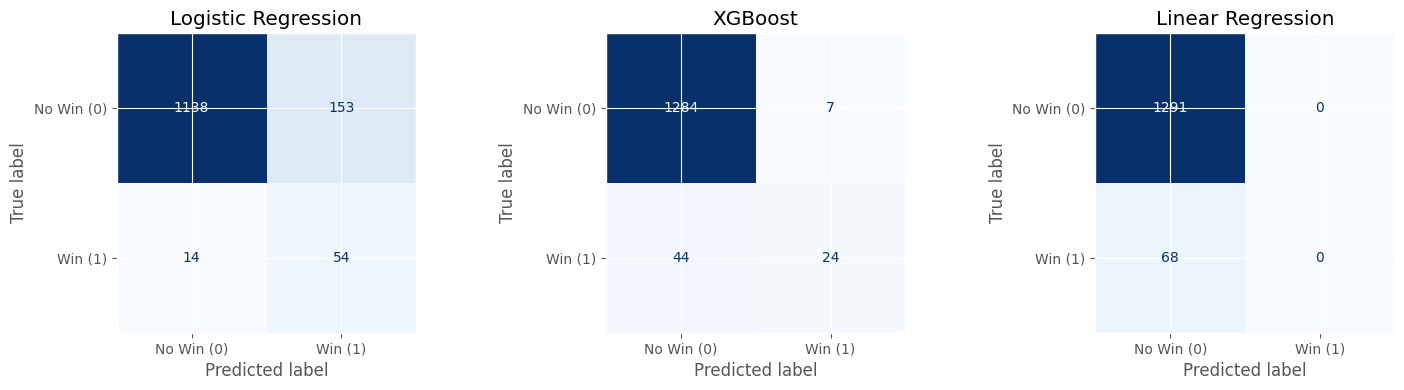

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

if "clean_df" not in globals():
    raise RuntimeError("Run the training/data-prep cells first so 'clean_df' exists.")

if "plt" not in globals():
    import matplotlib.pyplot as plt

train_df, test_df = time_split(clean_df)

target_col = "win"
drop_cols = [target_col, "driverId_code", "constructorId_code", "circuitId_code"]

x_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
x_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
y_train = train_df[target_col].astype(int)
y_test = test_df[target_col].astype(int)

numeric_features = [
    "year", "round", "grid", "quali_position", "driver_age",
    "driver_prior_races", "driver_prev_wins", "driver_prev_points",
    "driver_prev_avg_finish", "constructor_prior_races",
    "constructor_prev_wins", "constructor_prev_points",
    "constructor_prev_avg_finish", "driver_elo_pre", "constructor_elo_pre",
]
categorical_features = ["driverId", "constructorId", "circuitId"]

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=42,
            )),
        ]
    ),
    "Linear Regression": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", LinearRegression()),
        ]
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(x_train, y_train)

    if name == "Linear Regression":
        y_score = np.clip(model.predict(x_test), 0.0, 1.0)
        y_pred = (y_score >= 0.5).astype(int)
    else:
        y_pred = (model.predict_proba(x_test)[:, 1] >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Win (0)", "Win (1)"]
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    print(f"{name}\n{cm}\n")

plt.tight_layout()
plt.show()


## Visualizations
These charts summarize data quality, target balance, feature behavior, and model performance.

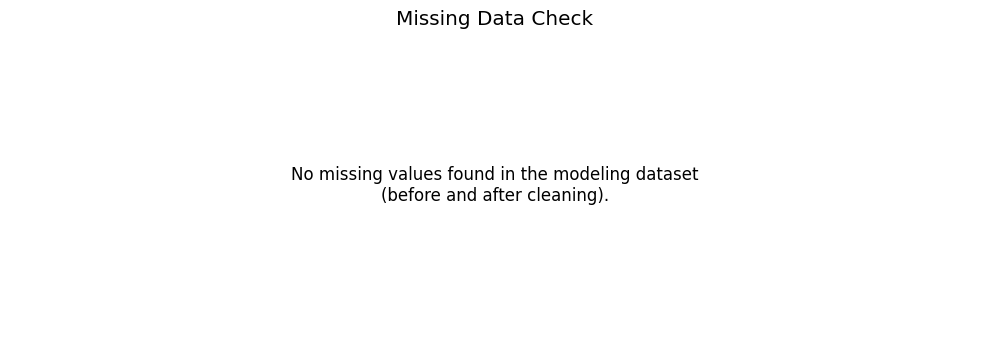

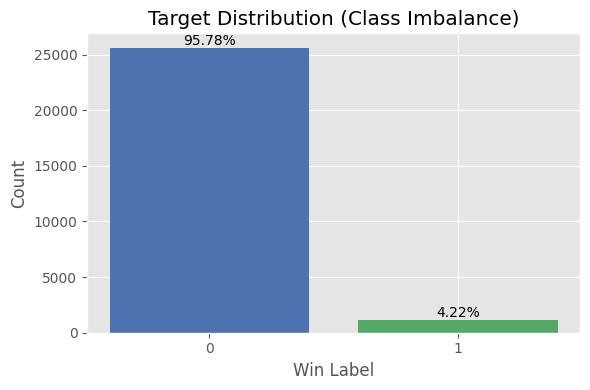

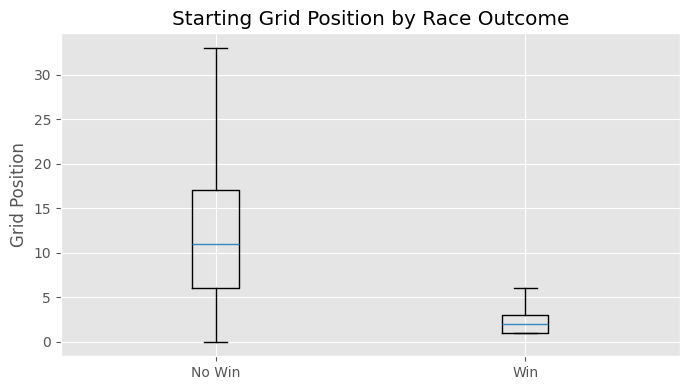

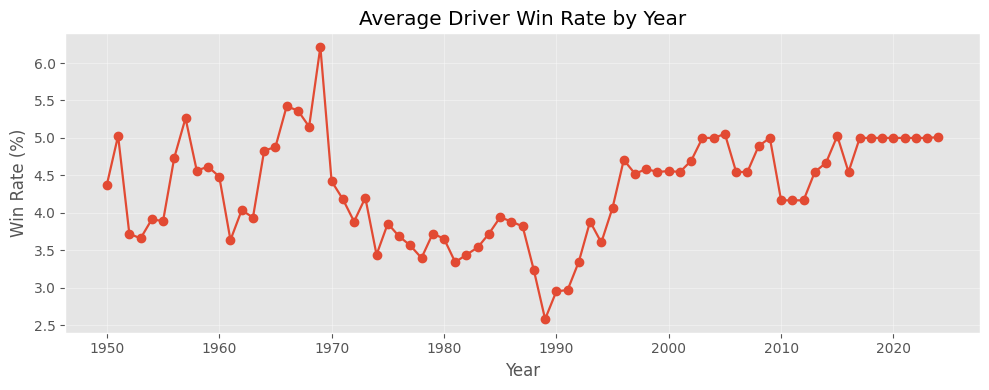

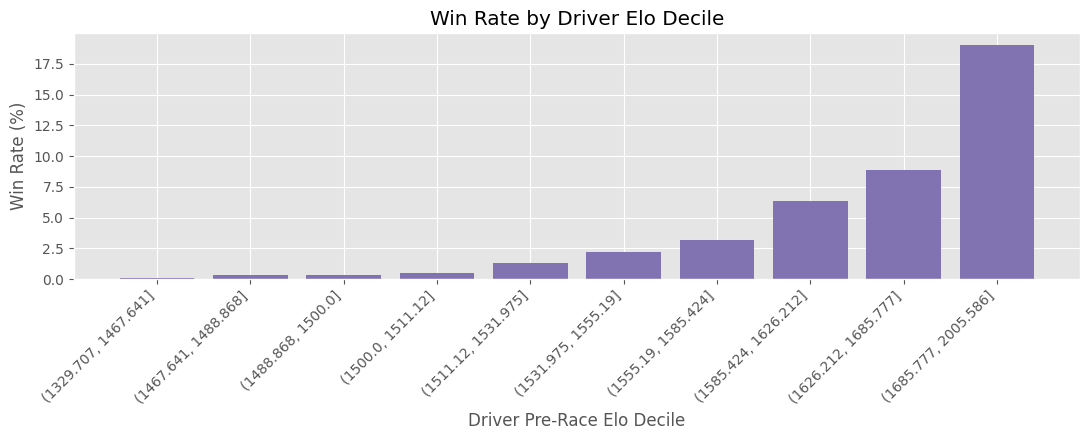

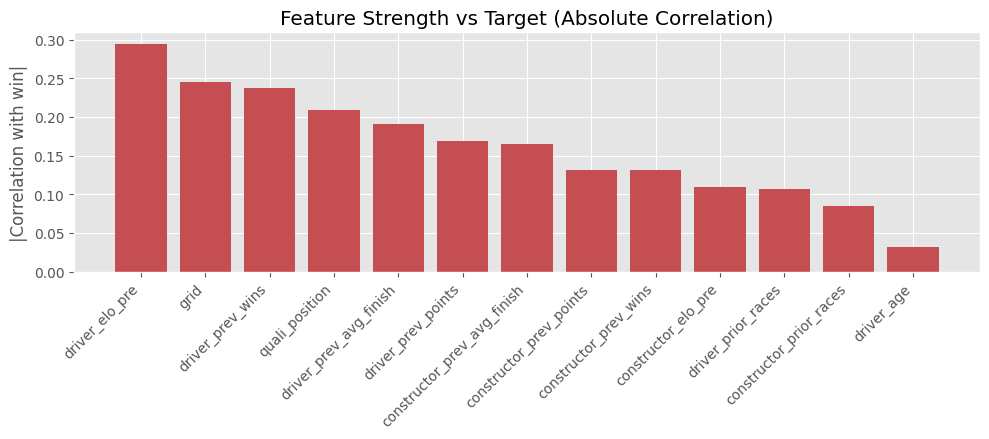

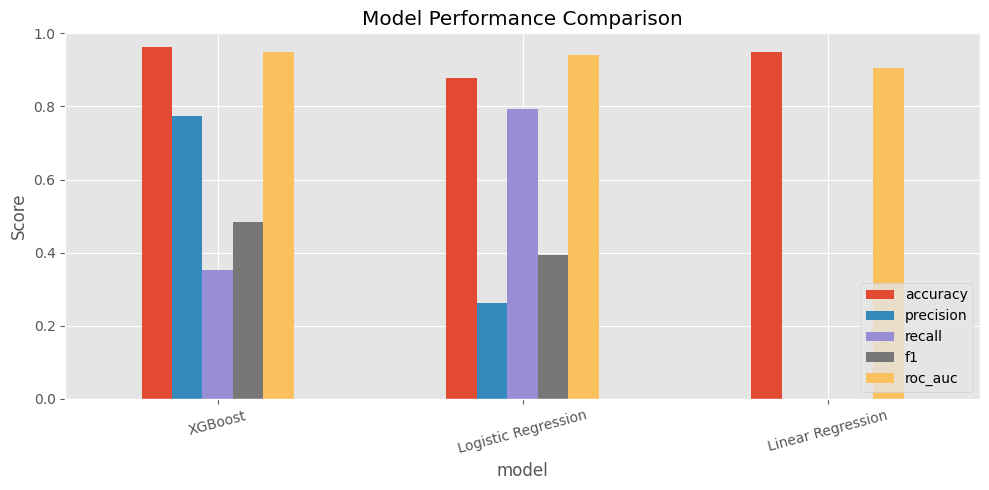

In [6]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

required_vars = [
    "clean_df",
    "missing_before",
    "missing_after",
    "target_distribution",
    "comparison_df",
]

for var_name in required_vars:
    if var_name not in globals():
        raise RuntimeError(
            f"Variable '{var_name}' not found. Run all previous cells first."
        )

# 1) Missing values before vs after cleaning.
missing_compare = (
    missing_before[["missing_pct"]]
    .rename(columns={"missing_pct": "before_pct"})
    .join(
        missing_after[["missing_pct"]].rename(columns={"missing_pct": "after_pct"}),
        how="left",
    )
    .fillna(0)
    .sort_values("before_pct", ascending=False)
    .head(10)
)

if float(missing_compare["before_pct"].sum()) == 0 and float(missing_compare["after_pct"].sum()) == 0:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.axis("off")
    ax.text(
        0.5,
        0.5,
        "No missing values found in the modeling dataset\n(before and after cleaning).",
        ha="center",
        va="center",
        fontsize=12,
    )
    ax.set_title("Missing Data Check", pad=12)
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    idx = range(len(missing_compare))
    ax.bar(idx, missing_compare["before_pct"], width=0.4, label="Before", alpha=0.85)
    ax.bar([i + 0.4 for i in idx], missing_compare["after_pct"], width=0.4, label="After", alpha=0.85)
    ax.set_xticks([i + 0.2 for i in idx])
    ax.set_xticklabels(missing_compare.index, rotation=45, ha="right")
    ax.set_ylabel("Missing (%)")
    ax.set_title("Top Missing Columns: Before vs After Cleaning")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 2) Target class balance.
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_distribution["win"].astype(str), target_distribution["count"], color=["#4C72B0", "#55A868"])
ax.set_xlabel("Win Label")
ax.set_ylabel("Count")
ax.set_title("Target Distribution (Class Imbalance)")
for x, y, pct in zip(target_distribution["win"].astype(str), target_distribution["count"], target_distribution["pct"]):
    ax.text(x, y, f"{pct}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# 3) Grid position by outcome.
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    [
        clean_df.loc[clean_df["win"] == 0, "grid"],
        clean_df.loc[clean_df["win"] == 1, "grid"],
    ],
    tick_labels=["No Win", "Win"],
    showfliers=False,
)
ax.set_ylabel("Grid Position")
ax.set_title("Starting Grid Position by Race Outcome")
plt.tight_layout()
plt.show()

# 4) Average win rate by year.
yearly_win = clean_df.groupby("year", as_index=False)["win"].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly_win["year"], yearly_win["win"] * 100, marker="o", linewidth=1.6)
ax.set_xlabel("Year")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Average Driver Win Rate by Year")
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()

# 5) Elo insight: win rate by driver Elo decile.
elo_view = clean_df.copy()
elo_view["driver_elo_decile"] = pd.qcut(
    elo_view["driver_elo_pre"],
    q=10,
    duplicates="drop",
)
elo_win_rate = (
    elo_view.groupby("driver_elo_decile", observed=False)["win"]
    .mean()
    .reset_index()
)
elo_win_rate["driver_elo_decile"] = elo_win_rate["driver_elo_decile"].astype(str)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(elo_win_rate["driver_elo_decile"], elo_win_rate["win"] * 100, color="#8172B2")
ax.set_xlabel("Driver Pre-Race Elo Decile")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Win Rate by Driver Elo Decile")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 6) Feature relevance proxy: absolute correlation with win.
numeric_for_corr = [
    "grid",
    "quali_position",
    "driver_age",
    "driver_prior_races",
    "driver_prev_wins",
    "driver_prev_points",
    "driver_prev_avg_finish",
    "constructor_prior_races",
    "constructor_prev_wins",
    "constructor_prev_points",
    "constructor_prev_avg_finish",
    "driver_elo_pre",
    "constructor_elo_pre",
    "win",
]

corr_target = (
    clean_df[numeric_for_corr]
    .corr(numeric_only=True)["win"]
    .drop("win")
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(corr_target.index, corr_target.values, color="#C44E52")
ax.set_title("Feature Strength vs Target (Absolute Correlation)")
ax.set_ylabel("|Correlation with win|")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7) Model comparison chart for key metrics.
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comparison_df.set_index("model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()